# Part 1

In [2]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

In [3]:
df = pd.read_excel("BuyList.xlsx", sheet_name = None)

In [4]:
df_bonds = df["BuyList"]
df_benchmark = df["Benchmark"]
df_nss = df["NSS"]
df_spline = df["Spline"]

In [5]:
df_bonds["Date"] = pd.to_datetime(df_bonds["Date"], errors="coerce")
df_bonds["Maturity"] = pd.to_datetime(df_bonds["Maturity"], errors="coerce")

In [6]:
def Tenor(start, maturity):
    num = (360 * (maturity.year - start.year)
           + 30 * (maturity.month - start.month)
           + (maturity.day - start.day))
    return num / 360

In [7]:
df_bonds["Tenor"] = df_bonds.apply(lambda row: Tenor(row["Date"], row["Maturity"]), axis=1)
df_bonds = df_bonds.dropna()

### Spread to Benchmark (T-Spread) = Bond yield – closest benchmark bond yield

In [9]:
## Finding nearest tenor to benchmark
def nearest_tenor(x):
    tenor = [0.5, 1.0, 2.0, 3.0, 5.0, 7.0, 10.0]
    x = float(x)
    idx = min(range(len(tenor)), key=lambda i: abs(tenor[i] - x))
    return tenor[idx]

In [10]:
df_bonds = df_bonds.copy()
df_bonds["benchmark_tenor"] = df_bonds["Tenor"].apply(nearest_tenor)
df_bonds

,Ticker,Coupon,Maturity,Sector,CreditRating,Yield,Date,Tenor,CUSIP,benchmark_tenor
0,AVGO,5.050,2027-07-12,Technology & Electronics,A,3.842,2025-10-15,1.741667,11135FBZ3,2.0
1,CARGIL,3.250,2029-05-23,Consumer Goods,A,4.004,2025-10-15,3.605556,141781BK9,3.0
2,CVX,3.250,2029-10-15,Energy,AA,3.842,2025-10-15,4.000000,166756AS5,3.0
3,KO,2.250,2032-01-05,Consumer Goods,A,4.029,2025-10-15,6.222222,191216DP2,7.0
4,GIS,4.875,2030-01-30,Consumer Goods,BBB,4.275,2025-10-15,4.291667,370334DA9,5.0
5,GM,2.350,2031-01-08,Automotive,BBB,4.666,2025-10-15,5.230556,37045XDE3,5.0
6,MS,5.948,2033-01-19,Financial Services,BBB,5.094,2025-10-15,7.261111,61747YFB6,7.0
7,NFLX,4.375,2026-11-15,Media,A,3.810,2025-10-15,1.083333,64110LAN6,1.0
8,NVDA,2.850,2030-04-01,Technology & Electronics,AA,3.862,2025-10-15,4.461111,67066GAF1,5.0
9,TMUS,5.300,2035-05-15,Telecommunications,BBB,4.856,2025-10-15,9.583333,87264ADT9,10.0


In [11]:
df_benchmark["benchmark_tenor"] = (df_benchmark["Maturity"] - df_benchmark["Date"]).dt.days / 360
df_benchmark["benchmark_tenor"]  = df_benchmark["benchmark_tenor"].apply(nearest_tenor)
df_benchmark2 = df_benchmark[["Yield", "benchmark_tenor"]]

In [12]:
df_bonds = pd.merge(df_bonds, df_benchmark2, on = 'benchmark_tenor')
df_bonds

,Ticker,Coupon,Maturity,Sector,CreditRating,Yield_x,Date,Tenor,CUSIP,benchmark_tenor,Yield_y
0,AVGO,5.050,2027-07-12,Technology & Electronics,A,3.842,2025-10-15,1.741667,11135FBZ3,2.0,3.498
1,CARGIL,3.250,2029-05-23,Consumer Goods,A,4.004,2025-10-15,3.605556,141781BK9,3.0,3.501
2,CVX,3.250,2029-10-15,Energy,AA,3.842,2025-10-15,4.000000,166756AS5,3.0,3.501
3,KO,2.250,2032-01-05,Consumer Goods,A,4.029,2025-10-15,6.222222,191216DP2,7.0,3.804
4,GIS,4.875,2030-01-30,Consumer Goods,BBB,4.275,2025-10-15,4.291667,370334DA9,5.0,3.617
5,GM,2.350,2031-01-08,Automotive,BBB,4.666,2025-10-15,5.230556,37045XDE3,5.0,3.617
6,MS,5.948,2033-01-19,Financial Services,BBB,5.094,2025-10-15,7.261111,61747YFB6,7.0,3.804
7,NFLX,4.375,2026-11-15,Media,A,3.810,2025-10-15,1.083333,64110LAN6,1.0,3.611
8,NVDA,2.850,2030-04-01,Technology & Electronics,AA,3.862,2025-10-15,4.461111,67066GAF1,5.0,3.617
9,TMUS,5.300,2035-05-15,Telecommunications,BBB,4.856,2025-10-15,9.583333,87264ADT9,10.0,4.029


### T Spread

In [14]:
df_bonds["T_spread"] = df_bonds["Yield_x"] - df_bonds["Yield_y"]
df_bonds["T_spread"]

0     0.344
1     0.503
2     0.341
3     0.225
4     0.658
5     1.049
6     1.290
7     0.199
8     0.245
9     0.827
10    0.993
11    0.709
Name: T_spread, dtype: float64

### Spread to the spot yield curve (Z-Spread) = bond yield – closest NSS spot yield

In [16]:
beta0 = float(df_nss["Beta0"].iloc[0])
beta1 = float(df_nss["Beta1"].iloc[0])
beta2 = float(df_nss["Beta2"].iloc[0])
beta3 = float(df_nss["Beta3"].iloc[0])
tau1  = float(df_nss["Tau1"].iloc[0])
tau2  = float(df_nss["Tau2"].iloc[0])

In [17]:
## function for NSS formula
def nss_spot_rate(m):
    """
    Compute NSS spot rate(s) S(m) for maturity m (years) using
    Nelson-Siegel-Svensson parameters.

    Formula:
      S(m) = beta0
           + beta1 * (1 - exp(-m/tau1)) / (m/tau1)
           + beta2 * ( (1 - exp(-m/tau1)) / (m/tau1) - exp(-m/tau1) )
           + beta3 * ( (1 - exp(-m/tau2)) / (m/tau2) - exp(-m/tau2) )
    """
    # Convert to numpy array for vectorized computation
    m_arr = np.asarray(m, dtype=float)

    # helper function: (1 - exp(-z)) / z with safe limit z->0 => 1
    def phi(z):
        with np.errstate(divide='ignore', invalid='ignore'):
            out = (1.0 - np.exp(-z)) / z
        out = np.where(z == 0.0, 1.0, out)
        return out

    # compute required pieces
    z1 = m_arr / float(tau1)
    z2 = m_arr / float(tau2)

    term1 = phi(z1)                      # (1 - exp(-m/tau1)) / (m/tau1)
    term2 = term1 - np.exp(-z1)         # term for beta2
    term3 = phi(z2) - np.exp(-z2)       # term for beta3

    spot = (float(beta0)
            + float(beta1) * term1
            + float(beta2) * term2
            + float(beta3) * term3)

    # return scalar
    if np.isscalar(m):
        return float(spot)
    return spot

In [18]:
df_bonds["Z_spread"] = df_bonds["Yield_x"] - df_bonds["Tenor"].apply(nss_spot_rate)

### Z Spread

In [20]:
df_bonds["Z_spread"]

0     0.326653
1     0.457011
2     0.270585
3     0.286899
4     0.683808
5     1.004552
6     1.263975
7     0.217637
8     0.258785
9     0.825667
10    0.867474
11    0.700479
Name: Z_spread, dtype: float64

### Spread to the government yield curve (G-Spread) = bond yield – closest cubic spline yield

In [22]:
df_spline["Tenor"] = df_spline.apply(lambda row: Tenor(row["Date"], row["Maturity"]), axis=1)
df_spline

,Date,Tenor,Yield,Maturity
0,2025-10-15,0.041667,4.074887,2025-10-30
1,2025-10-15,0.080556,4.039733,2025-11-14
2,2025-10-15,0.122222,4.026157,2025-11-29
3,2025-10-15,0.163889,3.939058,2025-12-14
4,2025-10-15,0.205556,3.918000,2025-12-29
...,...,...,...,...
246,2025-10-15,10.144444,4.001383,2035-12-07
247,2025-10-15,10.186111,3.996000,2035-12-22
248,2025-10-15,10.225000,3.990617,2036-01-06
249,2025-10-15,10.266667,3.985320,2036-01-21


In [23]:
## sorting by tenor
df_spline = df_spline.sort_values("Tenor")

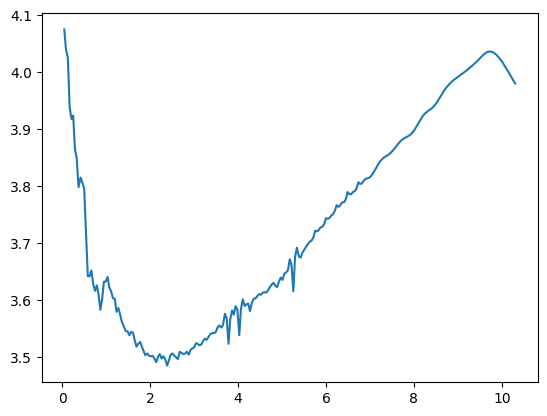

In [24]:
plt.plot(df_spline["Tenor"], df_spline["Yield"])

In [25]:
x = df_spline["Tenor"].values.astype(float)
y = df_spline["Yield"].values.astype(float)

In [26]:
cs = CubicSpline(x, y, bc_type="natural")

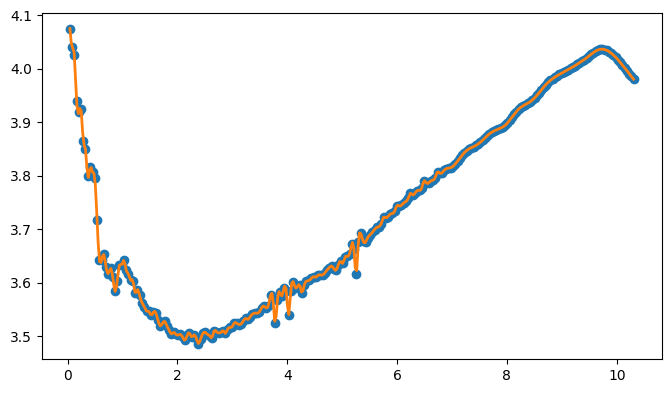

In [27]:
## Fitted curve
xx = np.linspace(x.min(), x.max(), 400)
yy = cs(xx)

# plot knots and fitted spline
plt.figure(figsize=(8,4.5))
plt.plot(x, y, "o", label="knots (data)")
plt.plot(xx, yy, "-", label="cubic spline fit", linewidth=2)

In [28]:
## Get bond tenors
t = df_bonds["Tenor"].values.astype(float)

## Evaluate spline at those tenors
df_bonds["Gov_Yield_Spline"] = cs(t)

### G Spread

In [30]:
df_bonds["G_spread"] = (df_bonds["Yield_x"] - df_bonds["Gov_Yield_Spline"])
df_bonds["G_spread"]

0     0.315733
1     0.450654
2     0.280477
3     0.266016
4     0.687636
5     1.028196
6     1.247689
7     0.190950
8     0.251776
9     0.825340
10    0.859605
11    0.702730
Name: G_spread, dtype: float64

# Part 2

In [32]:
df = pd.read_excel("Run.xlsx", sheet_name = None)

In [33]:
df_run =  df["Run"]
df_benchmark_ = df["Benchmark"]
df_nss_ = df["NSS"]
df_spline_ = df["Spline"]

In [34]:
df_run["Date"] = pd.to_datetime(df_run["Date"], errors="coerce")
df_run["Maturity"] = pd.to_datetime(df_run["Maturity"], errors="coerce")

In [35]:
df_run["Tenor"] = df_run.apply(lambda row: Tenor(row["Date"], row["Maturity"]), axis=1)
df_run = df_run.dropna()

### Bond Yield

In [37]:
df_run = df_run.copy()
df_run["benchmark_tenor"] = df_run["Tenor"].apply(nearest_tenor)
df_run

,Ticker,Coupon,Maturity,Sector,Credit Rating,Benchmark Spread,Date,Tenor,CUSIP,benchmark_tenor
0,BA,3.250,2028-02-01,Capital Goods,BBB,60,2025-10-23,2.272222,097023DB8,2.0
1,FANG,5.400,2034-04-18,Energy,BBB,94,2025-10-23,8.486111,25278XAZ2,7.0
2,F,2.900,2029-02-10,Automotive,BBB,157,2025-10-23,3.297222,345397B93,3.0
3,LHX,1.800,2031-01-15,Capital Goods,BBB,64,2025-10-23,5.227778,502431AN9,5.0
4,MCD,3.500,2027-07-01,Retail,BBB,35,2025-10-23,1.688889,58013MFP4,2.0
5,MSFT,3.400,2027-06-15,Technology & Electronics,AAA,2,2025-10-23,1.644444,594918CQ5,2.0
6,MDLZ,3.000,2032-03-17,Consumer Goods,BBB,62,2025-10-23,6.400000,609207BB0,7.0
7,PEP,4.550,2029-02-16,Consumer Goods,A,33,2025-10-23,3.313889,713466AB6,3.0
8,ROSW,5.593,2033-11-13,Healthcare,AAA,52,2025-10-23,8.055556,771196CH3,7.0
9,NOW,1.400,2030-09-01,Technology & Electronics,A,46,2025-10-23,4.855556,81762PAE2,5.0


In [38]:
df_benchmark_["benchmark_tenor"] = (df_benchmark_["Maturity"] - df_benchmark_["Date"]).dt.days / 360
df_benchmark_["benchmark_tenor"]  = df_benchmark_["benchmark_tenor"].apply(nearest_tenor)
df_benchmark2_ = df_benchmark_[["Yield", "benchmark_tenor"]]

In [39]:
df_run = pd.merge(df_run, df_benchmark2_, on = 'benchmark_tenor')
df_run.rename(columns={"Yield": "Yield_benchmark"}, inplace=True)
df_run

,Ticker,Coupon,Maturity,Sector,Credit Rating,Benchmark Spread,Date,Tenor,CUSIP,benchmark_tenor,Yield_benchmark
0,BA,3.250,2028-02-01,Capital Goods,BBB,60,2025-10-23,2.272222,097023DB8,2.0,3.480
1,FANG,5.400,2034-04-18,Energy,BBB,94,2025-10-23,8.486111,25278XAZ2,7.0,3.787
2,F,2.900,2029-02-10,Automotive,BBB,157,2025-10-23,3.297222,345397B93,3.0,3.488
3,LHX,1.800,2031-01-15,Capital Goods,BBB,64,2025-10-23,5.227778,502431AN9,5.0,3.605
4,MCD,3.500,2027-07-01,Retail,BBB,35,2025-10-23,1.688889,58013MFP4,2.0,3.480
5,MSFT,3.400,2027-06-15,Technology & Electronics,AAA,2,2025-10-23,1.644444,594918CQ5,2.0,3.480
6,MDLZ,3.000,2032-03-17,Consumer Goods,BBB,62,2025-10-23,6.400000,609207BB0,7.0,3.787
7,PEP,4.550,2029-02-16,Consumer Goods,A,33,2025-10-23,3.313889,713466AB6,3.0,3.488
8,ROSW,5.593,2033-11-13,Healthcare,AAA,52,2025-10-23,8.055556,771196CH3,7.0,3.787
9,NOW,1.400,2030-09-01,Technology & Electronics,A,46,2025-10-23,4.855556,81762PAE2,5.0,3.605


In [40]:
df_run["Yield"] = df_run["Yield_benchmark"] + df_run["Benchmark Spread"]/100

In [41]:
df_run["Yield"]

0     4.080
1     4.727
2     5.058
3     4.245
4     3.830
5     3.500
6     4.407
7     3.818
8     4.307
9     4.065
10    4.000
11    4.295
Name: Yield, dtype: float64

### Z Spread

In [43]:
beta0 = float(df_nss_["Beta0"].iloc[0])
beta1 = float(df_nss_["Beta1"].iloc[0])
beta2 = float(df_nss_["Beta2"].iloc[0])
beta3 = float(df_nss_["Beta3"].iloc[0])
tau1  = float(df_nss_["Tau1"].iloc[0])
tau2  = float(df_nss_["Tau2"].iloc[0])

In [44]:
df_run["Z_spread"] = df_run["Yield"] - df_run["Tenor"].apply(nss_spot_rate)

In [45]:
df_run["Z_spread"]

0     0.587800
1     0.821229
2     1.537931
3     0.599833
4     0.322099
5    -0.010653
6     0.670521
7     0.297134
8     0.436363
9     0.447359
10    0.506943
11    0.635948
Name: Z_spread, dtype: float64

### G Spread

In [47]:
## sorting by tenor
df_spline_ = df_spline_.sort_values("Tenor")

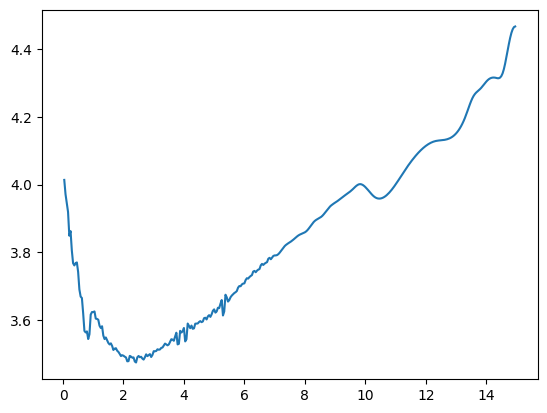

In [48]:
plt.plot(df_spline_["Tenor"], df_spline_["Yield"])

In [49]:
x = df_spline_["Tenor"].values.astype(float)
y = df_spline_["Yield"].values.astype(float)

In [50]:
cs = CubicSpline(x, y, bc_type="natural")

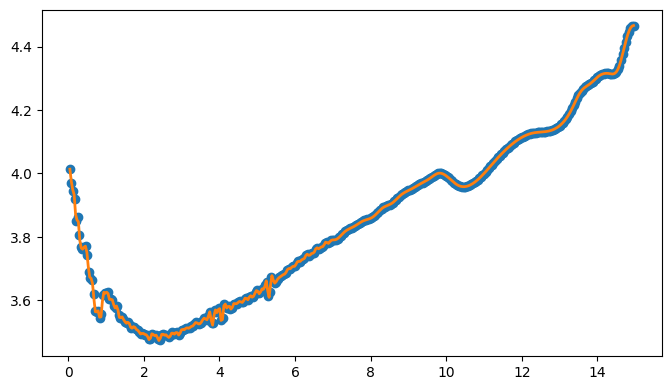

In [51]:
## Fitted curve
xx = np.linspace(x.min(), x.max(), 400)
yy = cs(xx)

# plot knots and fitted spline
plt.figure(figsize=(8,4.5))
plt.plot(x, y, "o", label="knots (data)")
plt.plot(xx, yy, "-", label="cubic spline fit", linewidth=2)

In [52]:
## Get bond tenors
t = df_run["Tenor"].values.astype(float)

## Evaluate spline at those tenors
df_run["Gov_Yield_Spline"] = cs(t)

In [53]:
df_run["G_spread"] = (df_run["Yield"] - df_run["Gov_Yield_Spline"])
df_run["G_spread"]

0     0.590562
1     0.825792
2     1.538650
3     0.586203
4     0.317478
5    -0.016871
6     0.663766
7     0.296530
8     0.444457
9     0.453786
10    0.517569
11    0.625038
Name: G_spread, dtype: float64

# Part 3

In [55]:
df = pd.read_excel("HistoricalData.xlsx")

In [56]:
df["Tenor"] = df.apply(lambda row: Tenor(row["Date"], row["Maturity"]), axis=1)

### CUSIP

In [58]:
## taking mean and std deviation for each cusip to calculate z-scores
grouped_cusip = df.groupby("CUSIP")
stats = grouped_cusip["Spread"].agg(["mean", "std"])
stats

,mean,std
CUSIP,,
097023DB8,75.366197,19.412462
25278XAZ2,122.450704,17.326067
345397B93,200.767606,35.234909
502431AN9,76.105634,15.199248
58013MFP4,34.492958,9.960736
594918CQ5,-7.802817,9.378744
609207BB0,75.676056,11.193684
713466AB6,37.570423,8.027787
771196CH3,58.401408,10.327310


In [59]:
## converting G_spread in bps
df_run.loc[:, "G_spread"] = pd.to_numeric(df_run["G_spread"], errors="coerce") * 100
df_cusip = df_run.loc[:, ["CUSIP", "G_spread", "Tenor", "Sector", "Credit Rating"]]
df_cusip

,CUSIP,G_spread,Tenor,Sector,Credit Rating
0,097023DB8,59.056177,2.272222,Capital Goods,BBB
1,25278XAZ2,82.579227,8.486111,Energy,BBB
2,345397B93,153.865010,3.297222,Automotive,BBB
3,502431AN9,58.620312,5.227778,Capital Goods,BBB
4,58013MFP4,31.747770,1.688889,Retail,BBB
5,594918CQ5,-1.687138,1.644444,Technology & Electronics,AAA
6,609207BB0,66.376573,6.400000,Consumer Goods,BBB
7,713466AB6,29.652988,3.313889,Consumer Goods,A
8,771196CH3,44.445676,8.055556,Healthcare,AAA
9,81762PAE2,45.378571,4.855556,Technology & Electronics,A


In [60]:
## Merging
df_cusip = pd.merge(df_cusip, stats, on = "CUSIP")
df_cusip

,CUSIP,G_spread,Tenor,Sector,Credit Rating,mean,std
0,097023DB8,59.056177,2.272222,Capital Goods,BBB,75.366197,19.412462
1,25278XAZ2,82.579227,8.486111,Energy,BBB,122.450704,17.326067
2,345397B93,153.865010,3.297222,Automotive,BBB,200.767606,35.234909
3,502431AN9,58.620312,5.227778,Capital Goods,BBB,76.105634,15.199248
4,58013MFP4,31.747770,1.688889,Retail,BBB,34.492958,9.960736
5,594918CQ5,-1.687138,1.644444,Technology & Electronics,AAA,-7.802817,9.378744
6,609207BB0,66.376573,6.400000,Consumer Goods,BBB,75.676056,11.193684
7,713466AB6,29.652988,3.313889,Consumer Goods,A,37.570423,8.027787
8,771196CH3,44.445676,8.055556,Healthcare,AAA,58.401408,10.327310
9,81762PAE2,45.378571,4.855556,Technology & Electronics,A,51.584507,10.143819


In [61]:
## Taking Z-scores
df_cusip["Z-score"] = (df_cusip["G_spread"] - df_cusip["mean"]) / df_cusip["std"]
df_cusip

,CUSIP,G_spread,Tenor,Sector,Credit Rating,mean,std,Z-score
0,097023DB8,59.056177,2.272222,Capital Goods,BBB,75.366197,19.412462,-0.840183
1,25278XAZ2,82.579227,8.486111,Energy,BBB,122.450704,17.326067,-2.301242
2,345397B93,153.865010,3.297222,Automotive,BBB,200.767606,35.234909,-1.331140
3,502431AN9,58.620312,5.227778,Capital Goods,BBB,76.105634,15.199248,-1.150407
4,58013MFP4,31.747770,1.688889,Retail,BBB,34.492958,9.960736,-0.275601
5,594918CQ5,-1.687138,1.644444,Technology & Electronics,AAA,-7.802817,9.378744,0.652079
6,609207BB0,66.376573,6.400000,Consumer Goods,BBB,75.676056,11.193684,-0.830780
7,713466AB6,29.652988,3.313889,Consumer Goods,A,37.570423,8.027787,-0.986254
8,771196CH3,44.445676,8.055556,Healthcare,AAA,58.401408,10.327310,-1.351342
9,81762PAE2,45.378571,4.855556,Technology & Electronics,A,51.584507,10.143819,-0.611795


In [62]:
# Highest zscore meaning highest yild and chepeast bond
print("Cheapest Bond CUSIP: ", df_cusip.loc[df_cusip["Z-score"].idxmax(), "CUSIP"])

Cheapest Bond CUSIP:  594918CQ5


### Highest spread per year tenor

In [64]:
# df["spread_per_year"] = df["Spread"]/df["Tenor"]

In [65]:
# ## taking mean and std deviation for each cusip to calculate z-scores
# grouped_cusip_ = df.groupby("CUSIP")
# stats = grouped_cusip_["spread_per_year"].agg(["mean", "std"])
# stats

In [66]:
## adding spread per year column in df_run
df_cusip["spread_per_year"] = df_cusip["G_spread"]/df_cusip["Tenor"]

In [67]:
print("Highest Spread Per Year Tenor CUSIP: ", df_cusip.loc[df_cusip["spread_per_year"].idxmax(), "CUSIP"])

Highest Spread Per Year Tenor CUSIP:  345397B93


In [68]:
# ## adding spread per year column
# df_cusip_ = df_run.loc[:, ["CUSIP", "spread_per_year"]]
# df_cusip_

In [69]:
# df_cusip_ = pd.merge(df_cusip_, stats, on = "CUSIP")
# df_cusip_

In [70]:
# ## Taking Z-scores
# df_cusip_["Z-score"] = (df_cusip_["spread_per_year"] - df_cusip_["mean"]) / df_cusip_["std"]
# df_cusip_

In [71]:
# # Highest zscore meaning highest yild and chepeast bond
# print("Highest Spread Per Year Tenor (Z-score) CUSIP: ", df_cusip_.loc[df_cusip_["Z-score"].idxmax(), "CUSIP"])

### Cheapest Sector

In [73]:
## 
df_sector = (df_cusip.groupby("Sector", as_index=False)["Z-score"].mean())
df_sector

,Sector,Z-score
0,Automotive,-1.331140
1,Capital Goods,-0.995295
2,Consumer Goods,-0.908517
3,Energy,-2.301242
4,Healthcare,-1.351342
5,Retail,-0.275601
6,Technology & Electronics,0.137078
7,Telecommunications,-1.058141


In [74]:
# ## taking mean and std deviation for each sector to calculate z-scores
# grouped_sector = df.groupby("ICESectorL3")
# stats = grouped_sector["Spread"].agg(mean="mean", std="std")
# stats = stats.rename_axis("Sector")  # rename index name
# stats

In [75]:
# ## Taking avg of G-spread for each sector from df_run
# df_sector = (df_run.groupby("Sector", as_index=False)["G_spread"].mean().rename(columns={"G_spread": "avg_G_spread"}))
# df_sector

In [76]:
# ## merging with stats
# df_sector = pd.merge(df_sector, stats, on = "Sector")

In [77]:
# df_sector["Z-score"] = (df_sector["avg_G_spread"] - df_sector["mean"])/df_sector["std"]
# df_sector

In [78]:
# Highest zscore meaning highest spread and chepeast sector
print("Cheapest Bond Sector: ", df_sector.loc[df_sector["Z-score"].idxmax(), "Sector"])

Cheapest Bond Sector:  Technology & Electronics


### Rating

In [80]:
df_rating = (df_cusip.groupby("Credit Rating", as_index=False)["Z-score"].mean())
df_rating

,Credit Rating,Z-score
0,A,-0.799024
1,AAA,-0.349632
2,BBB,-0.927068


In [81]:
# ## taking mean and std deviation for each Ratings to calculate z-scores
# grouped_rating = df.groupby("Rating")
# stats = grouped_rating["Spread"].agg(mean="mean", std="std")
# stats = stats.rename_axis("Rating")  # rename index name
# stats

In [82]:
# ## Taking avg of G-spread for each rating from df_run
# df_rating = (df_run.groupby("Credit Rating", as_index=False)["G_spread"].mean().rename(columns={"G_spread": "avg_G_spread", "Credit Rating": "Rating"}))
# df_rating

In [83]:
# ## merging with stats
# df_rating = pd.merge(df_rating, stats, on = "Rating")

In [84]:
# df_rating["Z-score"] = (df_rating["avg_G_spread"] - df_rating["mean"])/df_rating["std"]
# df_rating

In [87]:
# Highest zscore meaning highest spread and chepeast bond
print("Cheapest Bond Rating: ", df_rating.loc[df_rating["Z-score"].idxmax(), "Credit Rating"])

Cheapest Bond Rating:  AAA
